In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('dirty_cafe_sales.csv')
df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB


## had to change the data type, because object not giving any mean and other data points

In [4]:
df['Price Per Unit'] = pd.to_numeric(df['Price Per Unit'], errors='coerce')
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')
df['Quantity'] = df['Quantity'].astype('Int64')
df['Total Spent'] = pd.to_numeric(df['Total Spent'], errors='coerce')

In [5]:
df[['Quantity', 'Price Per Unit', 'Total Spent']].describe().round()

,Quantity,Price Per Unit,Total Spent
count,9521.0,9467.0,9498.0
mean,3.0,3.0,9.0
std,1.0,1.0,6.0
min,1.0,1.0,1.0
25%,2.0,2.0,4.0
50%,3.0,3.0,8.0
75%,4.0,4.0,12.0
max,5.0,5.0,25.0


In [6]:
df.shape

(10000, 8)

In [7]:
df.isnull().sum()/ len(df) * 100

Transaction ID       0.00
Item                 3.33
Quantity             4.79
Price Per Unit       5.33
Total Spent          5.02
Payment Method      25.79
Location            32.65
Transaction Date     1.59
dtype: float64

## Data show no duplicate

In [8]:
df[df.duplicated()]

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date


In [9]:
for col in df.columns:
    num = df[col].nunique()
    if num < 20:
        print(df[col].value_counts())
        print('#'*50)

Item
Juice       1171
Coffee      1165
Salad       1148
Cake        1139
Sandwich    1131
Smoothie    1096
Cookie      1092
Tea         1089
UNKNOWN      344
ERROR        292
Name: count, dtype: int64
##################################################
Quantity
5    2013
2    1974
4    1863
3    1849
1    1822
Name: count, dtype: Int64
##################################################
Price Per Unit
3.0    2429
4.0    2331
2.0    1227
5.0    1204
1.0    1143
1.5    1133
Name: count, dtype: int64
##################################################
Total Spent
6.0     979
12.0    939
3.0     930
4.0     923
20.0    746
15.0    734
8.0     677
10.0    524
2.0     497
9.0     479
5.0     468
16.0    444
25.0    259
7.5     237
1.0     232
4.5     225
1.5     205
Name: count, dtype: int64
##################################################
Payment Method
Digital Wallet    2291
Credit Card       2273
Cash              2258
ERROR              306
UNKNOWN            293
Name: count, dtype: int64

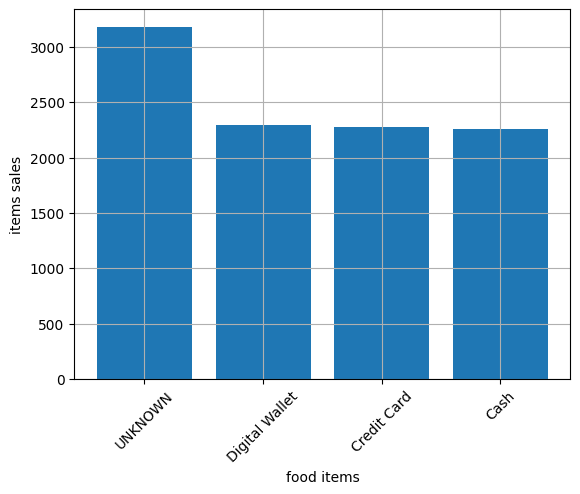

In [35]:
import matplotlib.pyplot as plt
itemdata = df['Payment Method'].value_counts()
plt.bar(itemdata.index, itemdata.values)
plt.xlabel('food items')
plt.ylabel('items sales')

plt.xticks(rotation=45)

plt.grid()
plt.show()

## Missing values fix

In [11]:
df['Item']=df['Item'].str.lower()
df['Item'] = df['Item'].replace('error', 'unknown')

In [12]:
quantMean = int(df['Quantity'].dropna().mean())
df.fillna({'Quantity': quantMean}, inplace = True)

In [13]:
df['Item'].unique()

array(['coffee', 'cake', 'cookie', 'salad', 'smoothie', 'unknown',
       'sandwich', nan, 'juice', 'tea'], dtype=object)

In [14]:
df['Price Per Unit'].unique()

array([2. , 3. , 1. , 5. , 4. , 1.5, nan])

In [15]:
priceMean = df['Price Per Unit'].dropna().mean()
df.fillna({'Price Per Unit': priceMean}, inplace = True)
df['Price Per Unit'] = df['Price Per Unit'].round(1)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    10000 non-null  object 
 1   Item              9667 non-null   object 
 2   Quantity          10000 non-null  Int64  
 3   Price Per Unit    10000 non-null  float64
 4   Total Spent       9498 non-null   float64
 5   Payment Method    7421 non-null   object 
 6   Location          6735 non-null   object 
 7   Transaction Date  9841 non-null   object 
dtypes: Int64(1), float64(2), object(5)
memory usage: 634.9+ KB


In [36]:
TotalMean = df['Total Spent'].dropna().mean()
df.fillna({'Total Spent': TotalMean}, inplace = True)
df['Total Spent'] = df['Total Spent'].round(1)

In [18]:
df[df['Item']=='unknown']

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
6,TXN_4433211,unknown,3,3.0,9.0,ERROR,Takeaway,2023-10-06
14,TXN_8915701,unknown,2,1.5,3.0,NaN,In-store,2023-03-21
31,TXN_8927252,unknown,2,1.0,8.9,Credit Card,ERROR,2023-11-06
33,TXN_7710508,unknown,5,1.0,5.0,Cash,NaN,ERROR
36,TXN_6855453,unknown,4,3.0,12.0,NaN,In-store,2023-07-17
...,...,...,...,...,...,...,...,...
9946,TXN_8807600,unknown,1,4.0,4.0,Cash,Takeaway,2023-09-24
9951,TXN_4122925,unknown,4,1.0,4.0,NaN,Takeaway,2023-10-20
9958,TXN_4125474,unknown,2,5.0,10.0,Credit Card,In-store,2023-08-02
9981,TXN_4583012,unknown,5,4.0,20.0,Digital Wallet,NaN,2023-02-27


In [19]:
df[df['Item'].isnull()]

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
8,TXN_4717867,NaN,5,3.0,15.0,NaN,Takeaway,2023-07-28
30,TXN_1736287,NaN,5,2.0,10.0,Digital Wallet,NaN,2023-06-02
61,TXN_8051289,NaN,1,3.0,3.0,NaN,In-store,2023-10-09
72,TXN_6044979,NaN,1,1.0,1.0,Cash,In-store,2023-12-08
89,TXN_4132730,NaN,5,1.0,5.0,NaN,In-store,2023-03-12
...,...,...,...,...,...,...,...,...
9820,TXN_8751702,NaN,5,2.9,15.0,Cash,NaN,2023-02-13
9855,TXN_3740505,NaN,2,1.5,3.0,NaN,NaN,2023-11-21
9876,TXN_3105633,NaN,1,2.0,2.0,NaN,In-store,2023-03-30
9885,TXN_4659954,NaN,3,4.0,12.0,Credit Card,In-store,NaN


## Item column have almost 90% of data as unknowen or null.
* removing the column is better
* as inputatin will make the data irrelavent

In [20]:
df.drop(columns=['Item'], inplace=True)

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    10000 non-null  object 
 1   Quantity          10000 non-null  Int64  
 2   Price Per Unit    10000 non-null  float64
 3   Total Spent       10000 non-null  float64
 4   Payment Method    7421 non-null   object 
 5   Location          6735 non-null   object 
 6   Transaction Date  9841 non-null   object 
dtypes: Int64(1), float64(2), object(4)
memory usage: 556.8+ KB


### UNKNOWN, ERROR these have to removed form the date column

In [22]:
# fresh_date = df[(df['Transaction Date'] != 'UNKNOWN') & (df['Transaction Date'] !='ERROR')]['Transaction Date'].dropna()
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'], errors='coerce')

In [28]:
df.fillna({'Transaction Date': 'ffill'}, inplace=True)

In [29]:
df[df['Transaction Date'].isnull()]

,Transaction ID,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date


## removed the unwanted category and put nan there 
## put UNKNOWN in place of those nan

In [41]:
df['Payment Method'].unique()

array(['Credit Card', 'Cash', 'UNKNOWN', 'Digital Wallet'], dtype=object)

In [33]:
df['Payment Method'] = df['Payment Method'].replace(['UNKNOWN', 'ERROR'], 'UNKNOWN')
df.fillna({'Payment Method': 'UNKNOWN'}, inplace=True)

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    10000 non-null  object        
 1   Quantity          10000 non-null  Int64         
 2   Price Per Unit    10000 non-null  float64       
 3   Total Spent       10000 non-null  float64       
 4   Payment Method    10000 non-null  object        
 5   Location          10000 non-null  object        
 6   Transaction Date  10000 non-null  datetime64[ns]
dtypes: Int64(1), datetime64[ns](1), float64(2), object(3)
memory usage: 556.8+ KB


## have put the UNKNOWN category in , place of error and nan values. 
## 32 percent data was missing , imputation will cau

In [44]:
df['Location'].unique()

array(['Takeaway', 'In-store', 'UNKNOWN'], dtype=object)

In [43]:
df['Location'] = df['Location'].replace(['UNKNOWN','ERROR'], 'UNKNOWN')
df.fillna({'Location': 'UNKNOWN'}, inplace=True)